# 01 - Análisis Descriptivo Exploratorio (ADE) — v2

## Proyecto: "¿Regular o no regular? Impacto de la regulación de IA en los ecosistemas nacionales"

**Contexto:** Chile - Boletín 16821-19 (Ley Marco de IA)
**Curso:** IMT3860, Pontificia Universidad Católica de Chile, abril 2026

---

## Objetivos del ADE v2

1. Comprender la estructura del dataset final (86 países × 105 variables)
2. Mapear el estado de extracción del **corpus legal-IA** (38/86 procesados)
3. Comparar la codificación X1 **IAPP base** contra la **propuesta por la skill `corpus-legal-ia`** (41 países)
4. Identificar patrones en regulación IA (X1) y resultados del ecosistema (Y)
5. Detectar relaciones preliminares entre regulación y desarrollo del ecosistema IA
6. Documentar nuevas variables derivadas del corpus (`has_dedicated_ai_authority`, `ai_law_pathway_declared`, métricas del corpus)
7. Preparar el terreno para el modelamiento estadístico

## Cambios respecto a v1 del ADE

| Elemento | v1 | v2 |
|---|---|---|
| Fuente X1 principal | `sample_ready_cross_section.csv` (IAPP) | + `x1_master_v2.csv` (IAPP **+** propuestas corpus-legal-IA) |
| Cobertura corpus | 23 países | 38 países en muestra (+QAT externo, +KAZ pendiente) |
| Variables nuevas | — | `has_dedicated_ai_authority`, `ai_law_pathway_declared`, `ai_corpus_n_documents`, `ai_corpus_total_pages`, `ai_corpus_years_span` |
| Comparación IAPP vs Propuesta | — | Sección dedicada con diff plots |
| Status del corpus por país | — | Tabla y mapa de cobertura por región |

> **Alcance:** Este ADE describe el dataset completo (N=86) tal como está hoy. El sub-estudio MVP Top 30 con N=30 (incluyendo análisis SCM de CHL) está en desarrollo separado y NO se reporta aquí.


## 1. Setup y Carga de Datos

In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Rutas
DATA_PATH = '../data/interim/'
LEGAL_CORPUS_PATH = '../data/raw/legal_corpus/'
OUTPUTS_PATH = './outputs/'

import os
os.makedirs(OUTPUTS_PATH, exist_ok=True)

print("✓ Setup completado")

✓ Setup completado


In [9]:
# Cargar dataset principal (86 paises)
df = pd.read_csv(f'{DATA_PATH}sample_ready_cross_section.csv')
print(f"sample_ready_cross_section.csv: {df.shape[0]} países × {df.shape[1]} variables")

# Cargar x1_master_v2 (corpus legal-IA propuestas)
x1v2 = pd.read_csv(f'{DATA_PATH}x1_master_v2.csv')
print(f"x1_master_v2.csv: {x1v2.shape[0]} países procesados por skill corpus-legal-ia")

# Cargar x1_master original (IAPP base) para comparacion
x1v1 = pd.read_csv(f'{DATA_PATH}x1_master.csv')
print(f"x1_master.csv (IAPP base): {x1v1.shape[0]} países")

sample_ready_cross_section.csv: 86 países × 105 variables
x1_master_v2.csv: 41 países procesados por skill corpus-legal-ia
x1_master.csv (IAPP base): 86 países


## 2. Estado Actual del Proyecto

Este bloque documenta:
- Cuántos países tienen corpus legal-IA extraído
- Cuántos están pendientes
- Cobertura por prioridad (P1-TOP30 vs P2-IAPP-LOW vs P3-SAMPLE)

In [10]:
# 2.1 Cobertura del corpus legal-IA (carpetas en data/raw/legal_corpus/)
import os
corpus_dirs = [d for d in os.listdir(LEGAL_CORPUS_PATH)
               if os.path.isdir(os.path.join(LEGAL_CORPUS_PATH, d)) and len(d) == 3]
corpus_set = set(corpus_dirs)
sample_set = set(df['iso3'].tolist())

in_sample_done = corpus_set & sample_set
out_sample_done = corpus_set - sample_set
pending = sample_set - corpus_set

print(f"=== ESTADO DE EXTRACCIÓN DEL CORPUS LEGAL-IA ===\n")
print(f"Países con corpus extraído (carpeta DONE): {len(corpus_set)}")
print(f"  - Dentro de muestra (86): {len(in_sample_done)}")
print(f"  - Fuera de muestra (referencia): {len(out_sample_done)}  → {sorted(out_sample_done)}")
print(f"\nPaíses de la muestra PENDIENTES de corpus: {len(pending)}")
print(f"  Pendientes: {sorted(pending)}")
print(f"\n📊 Tasa de avance corpus: {len(in_sample_done)}/{len(sample_set)} = {100*len(in_sample_done)/len(sample_set):.1f}%")

=== ESTADO DE EXTRACCIÓN DEL CORPUS LEGAL-IA ===

Países con corpus extraído (carpeta DONE): 42
  - Dentro de muestra (86): 41
  - Fuera de muestra (referencia): 1  → ['QAT']

Países de la muestra PENDIENTES de corpus: 45
  Pendientes: ['ARG', 'BLZ', 'BRA', 'BRB', 'CHL', 'COL', 'CYP', 'ECU', 'EGY', 'EST', 'GRC', 'HRV', 'IDN', 'ISL', 'KEN', 'LKA', 'LTU', 'LUX', 'LVA', 'MAR', 'MEX', 'MLT', 'MUS', 'MYS', 'NGA', 'PAK', 'PAN', 'PER', 'PHL', 'PRT', 'ROU', 'RUS', 'SAU', 'SRB', 'SVK', 'SVN', 'SYC', 'THA', 'TUN', 'TUR', 'UGA', 'UKR', 'URY', 'VNM', 'ZAF']

📊 Tasa de avance corpus: 41/86 = 47.7%


In [11]:
# 2.2 X1 propuestas (skill corpus-legal-ia) por país
# x1_master_v2.csv tiene una fila por cada CANDIDATES.md procesado
print(f"=== X1 PROPUESTAS DESDE CORPUS LEGAL-IA ===\n")
print(f"Total países con CANDIDATES.md parseado: {len(x1v2)}")
n_with_intensity = x1v2['regulatory_intensity_proposed'].notna().sum()
n_with_coverage = x1v2['thematic_coverage_proposed'].notna().sum()
n_with_regime = x1v2['regulatory_regime_group_proposed'].notna().sum()
print(f"  - Con regulatory_intensity_proposed: {n_with_intensity}")
print(f"  - Con thematic_coverage_proposed: {n_with_coverage}")
print(f"  - Con regulatory_regime_group_proposed: {n_with_regime}")
print(f"  - Con has_dedicated_ai_authority codificado: {(x1v2['has_dedicated_ai_authority']==1).sum()}")
print(f"  - Con ai_law_pathway_declared = 1: {(x1v2['ai_law_pathway_declared']==1).sum()}")

=== X1 PROPUESTAS DESDE CORPUS LEGAL-IA ===

Total países con CANDIDATES.md parseado: 41
  - Con regulatory_intensity_proposed: 20
  - Con thematic_coverage_proposed: 19
  - Con regulatory_regime_group_proposed: 29
  - Con has_dedicated_ai_authority codificado: 24
  - Con ai_law_pathway_declared = 1: 23


                                         done  total  pct_done
region                                                        
Northern America                            2      2     100.0
South East Asia, East Asia, and Oceania     8     13      61.5
Central and Southern Asia                   3      5      60.0
Europe                                     19     34      55.9
Northern Africa and Western Asia            6     12      50.0
Sub-Saharan Africa                          2      8      25.0
Latin America and the Caribbean             1     12       8.3


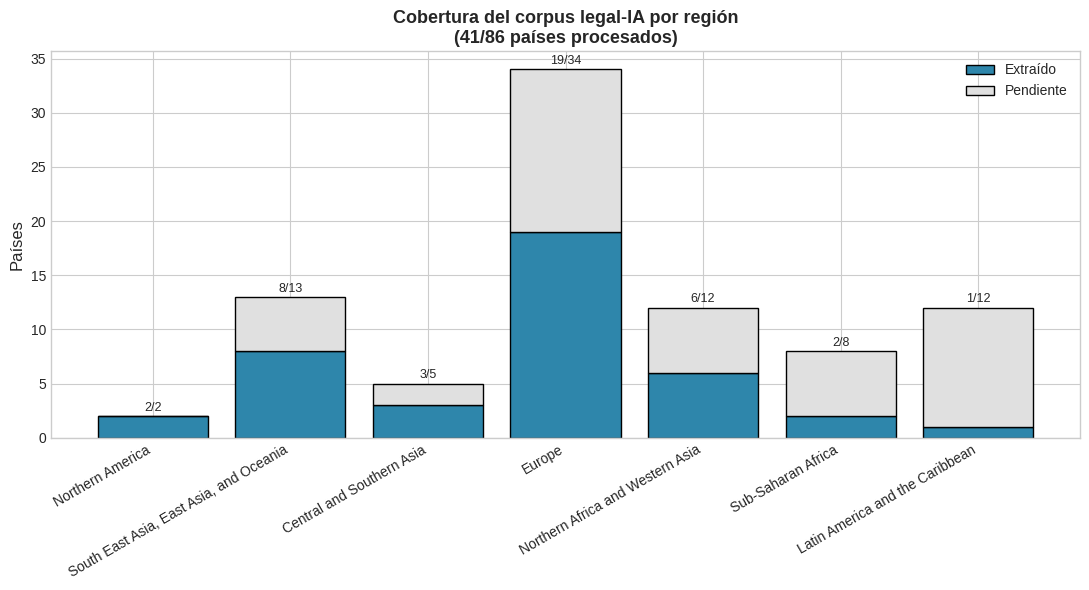


✓ Guardado: ade_v2_00_corpus_coverage_by_region.png


In [12]:
# 2.3 Visualización: cobertura corpus por estado y región
df_corpus_status = df[['iso3','region']].copy()
df_corpus_status['has_corpus'] = df_corpus_status['iso3'].isin(in_sample_done).astype(int)

cobertura = df_corpus_status.groupby('region')['has_corpus'].agg(['sum','count'])
cobertura['pct'] = (cobertura['sum'] / cobertura['count'] * 100).round(1)
cobertura.columns = ['done', 'total', 'pct_done']
cobertura = cobertura.sort_values('pct_done', ascending=False)
print(cobertura)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(cobertura))
ax.bar(x, cobertura['done'], color='#2E86AB', label='Extraído', edgecolor='black')
ax.bar(x, cobertura['total'] - cobertura['done'], bottom=cobertura['done'],
       color='#E0E0E0', label='Pendiente', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(cobertura.index, rotation=30, ha='right')
ax.set_ylabel('Países', fontsize=12)
ax.set_title('Cobertura del corpus legal-IA por región\n'
             f'({len(in_sample_done)}/{len(sample_set)} países procesados)',
             fontsize=13, fontweight='bold')
for i, (done, total) in enumerate(zip(cobertura['done'], cobertura['total'])):
    ax.text(i, total + 0.5, f'{done}/{total}', ha='center', fontsize=9)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_v2_00_corpus_coverage_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Guardado: ade_v2_00_corpus_coverage_by_region.png")

## 3. Filtrar a Muestra Principal

In [13]:
# Flags de completitud disponibles
print("=== Flags de completitud (sample_ready) ===")
for flag in ['complete_principal', 'complete_confounded', 'complete_extended',
             'complete_digital', 'complete_regime', 'complete_legal_tradition']:
    if flag in df.columns:
        print(f"  {flag}: {df[flag].sum()}/{len(df)}")

=== Flags de completitud (sample_ready) ===
  complete_principal: 72/86
  complete_confounded: 72/86
  complete_extended: 62/86
  complete_digital: 69/86
  complete_regime: 72/86
  complete_legal_tradition: 72/86


In [14]:
# Filtrar a muestra principal
df_ade = df[df['complete_principal'] == 1].copy()
df_confounded = df[df['complete_confounded'] == 1].copy()
print(f"\n✓ Análisis principal: {len(df_ade)} países (muestra PRINCIPAL)")
print(f"✓ Análisis confounded: {len(df_confounded)} países")

# Cuántos de los df_ade tienen también corpus extraído
df_ade_with_corpus = df_ade[df_ade['iso3'].isin(in_sample_done)]
print(f"\nIntersección muestra principal × corpus DONE: {len(df_ade_with_corpus)}")


✓ Análisis principal: 72 países (muestra PRINCIPAL)
✓ Análisis confounded: 72 países

Intersección muestra principal × corpus DONE: 39


## 4. Definir Variables Clave

In [15]:
# Variables Y (Resultado - Ecosistema IA)
y_vars = [
    'ai_readiness_score',
    'ai_adoption_rate',
    'ai_investment_usd_bn_cumulative',
    'ai_startups_cumulative',
    'ai_patents_per100k'
]

# Variables X1 IAPP (codificación base)
x1_vars = [
    'has_ai_law',
    'regulatory_approach',
    'regulatory_intensity',
    'enforcement_level',
    'thematic_coverage',
    'regulatory_status_group'
]

# Variables X1 propuestas (corpus-legal-ia, en x1_master_v2)
x1_proposed_vars = [
    'has_ai_law_proposed',
    'regulatory_intensity_proposed',
    'thematic_coverage_proposed',
    'regulatory_regime_group_proposed',
    'enforcement_level_proposed',
]

# Variables NUEVAS derivadas del corpus (binarias / numéricas)
x1_corpus_extras = [
    'has_dedicated_ai_authority',
    'ai_law_pathway_declared',
    'ai_corpus_n_documents',
    'ai_corpus_total_pages',
    'ai_corpus_years_span',
]

# Variables X2 (Controles)
x2_core_vars = [
    'gdp_per_capita_ppp',
    'internet_penetration',
    'gii_score',
    'rd_expenditure',
    'tertiary_education'
]

x2_confounders = [
    'regulatory_quality',
    'rule_of_law',
    'has_gdpr_like_law',
    'gdpr_similarity_level',
    'fh_total_score',
    'legal_origin',
    'is_common_law'
]

print("Variables definidas:")
print(f"  Y (Resultado): {len(y_vars)}")
print(f"  X1 IAPP base: {len(x1_vars)}")
print(f"  X1 propuestas corpus: {len(x1_proposed_vars)}")
print(f"  X1 extras del corpus: {len(x1_corpus_extras)}")
print(f"  X2 Core: {len(x2_core_vars)}")
print(f"  X2 Confounders: {len(x2_confounders)}")

Variables definidas:
  Y (Resultado): 5
  X1 IAPP base: 6
  X1 propuestas corpus: 5
  X1 extras del corpus: 5
  X2 Core: 5
  X2 Confounders: 7


## 5. Estadísticas Descriptivas Generales

In [16]:
# 5.1 Resumen variables Y
print("=== Variables Y (Ecosistema IA) ===")
desc_y = df_ade[y_vars].describe()
print(desc_y.round(2))

=== Variables Y (Ecosistema IA) ===
       ai_readiness_score  ai_adoption_rate  ai_investment_usd_bn_cumulative  \
count               72.00             72.00                            72.00   
mean                60.89             23.86                            10.45   
std                 12.43             12.25                            56.93   
min                 32.47              6.60                             0.00   
25%                 53.72             14.68                             0.02   
50%                 60.90             22.45                             0.33   
75%                 69.97             28.98                             2.19   
max                 88.36             64.00                           470.92   

       ai_startups_cumulative  ai_patents_per100k  
count                   72.00               49.00  
mean                   198.75                0.85  
std                    842.19                2.71  
min                      1.00      

In [17]:
# 5.2 Resumen variables X1 IAPP
print("\n=== Variables X1 IAPP base ===")
print("\nhas_ai_law:")
print(df_ade['has_ai_law'].value_counts())

print("\nregulatory_approach:")
print(df_ade['regulatory_approach'].value_counts())

print("\nregulatory_status_group:")
print(df_ade['regulatory_status_group'].value_counts())

print("\nenforcement_level:")
print(df_ade['enforcement_level'].value_counts())


=== Variables X1 IAPP base ===

has_ai_law:
has_ai_law
0    44
1    28
Name: count, dtype: int64

regulatory_approach:
regulatory_approach
strategy_led     33
comprehensive    28
light_touch       9
none              2
Name: count, dtype: int64

regulatory_status_group:
regulatory_status_group
strategy_only         33
binding_regulation    28
soft_framework         9
no_framework           2
Name: count, dtype: int64

enforcement_level:
enforcement_level
high      27
low       24
medium    13
none       8
Name: count, dtype: int64


In [18]:
# 5.3 X1 numericas
print("\n=== regulatory_intensity (0-10) ===")
print(df_ade['regulatory_intensity'].describe().round(2))
print("\n=== thematic_coverage (0-15) ===")
print(df_ade['thematic_coverage'].describe().round(2))


=== regulatory_intensity (0-10) ===
count    72.0
mean      5.5
std       3.5
min       0.0
25%       3.0
50%       4.0
75%      10.0
max      10.0
Name: regulatory_intensity, dtype: float64

=== thematic_coverage (0-15) ===
count    72.00
mean      8.72
std       4.69
min       0.00
25%       5.00
50%       8.50
75%      14.00
max      14.00
Name: thematic_coverage, dtype: float64


In [19]:
# 5.4 X2 Core
print("\n=== X2 Core (Controles) ===")
print(df_ade[x2_core_vars].describe().round(2))


=== X2 Core (Controles) ===
       gdp_per_capita_ppp  internet_penetration  gii_score  rd_expenditure  \
count               72.00                 72.00      72.00           65.00   
mean             44775.63                 84.32      38.43            1.48   
std              29782.71                 16.66      12.74            1.25   
min               3273.27                  8.95      17.07            0.08   
25%              18958.22                 81.80      28.45            0.55   
50%              43148.33                 88.62      37.14            1.15   
75%              62010.68                 94.37      48.66            2.10   
max             150689.30                100.00      65.96            6.02   

       tertiary_education  
count               69.00  
mean                67.98  
std                 27.17  
min                 10.42  
25%                 53.46  
50%                 70.45  
75%                 81.18  
max                165.11  


## 6. Análisis del Corpus Legal-IA (38 países procesados)

Esta sección describe lo que la skill `corpus-legal-ia` extrajo de los 38 países donde
la carpeta `data/raw/legal_corpus/{ISO3}/` existe con sus 4 entregables (manifest.csv +
SOURCES.md + CANDIDATES.md + FINDINGS.md). El sub-estudio MVP Top 30 NO se cubre aquí.

In [20]:
# 6.1 Distribución del régimen propuesto por la skill
regime_proposed = x1v2['regulatory_regime_group_proposed'].value_counts(dropna=False)
print("=== regulatory_regime_group PROPUESTO por skill ===")
print(regime_proposed)

# Nota: 'NaN' = no se detectó propuesta explícita en CANDIDATES.md (formato distinto)
# pero el país sí está procesado
print(f"\nTotal con propuesta clara: {x1v2['regulatory_regime_group_proposed'].notna().sum()}/{len(x1v2)}")

=== regulatory_regime_group PROPUESTO por skill ===
regulatory_regime_group_proposed
soft_framework        18
NaN                   12
binding_regulation     9
strategy_only          2
Name: count, dtype: int64

Total con propuesta clara: 29/41


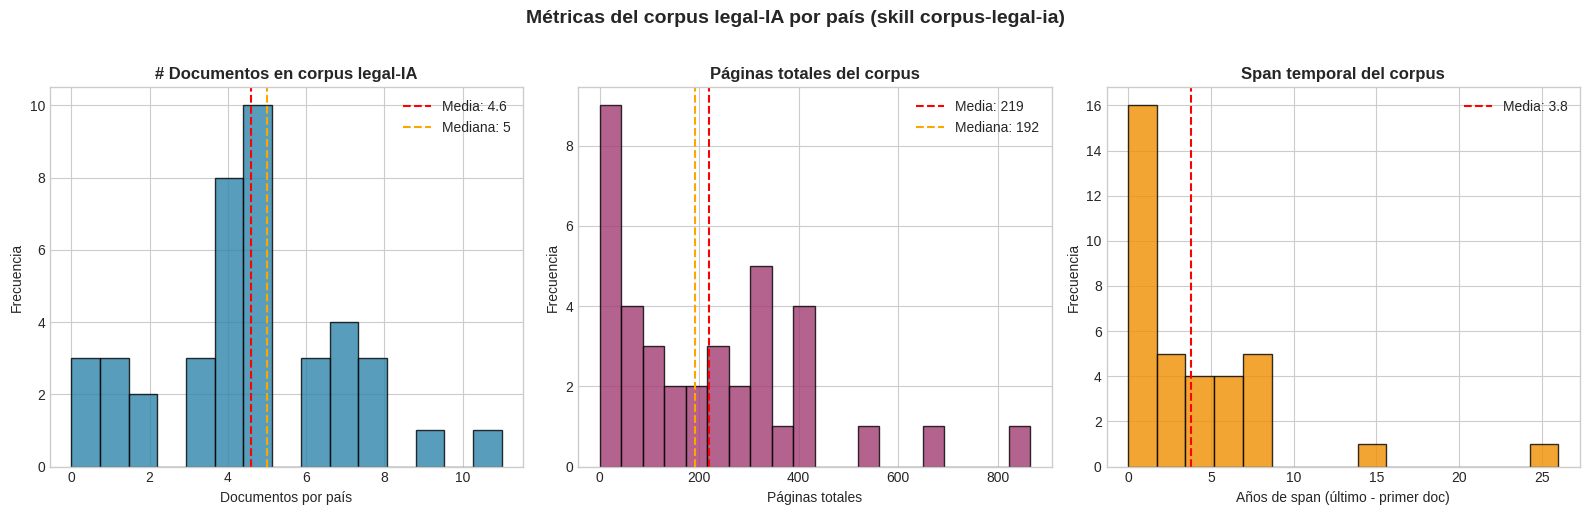


✓ Guardado: ade_v2_01_corpus_metrics.png

Páises con MÁS documentos:
   iso3  ai_corpus_n_documents  ai_corpus_total_pages
27  JPN                     11                  369.0
40  USA                      9                    NaN
14  DEU                      8                  410.0
17  FIN                      8                  681.0
19  GBR                      8                  865.0


In [21]:
# 6.2 Métricas del corpus por país
# Histogramas de n_documents y total_pages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Documentos
ax = axes[0]
docs_data = x1v2['ai_corpus_n_documents'].dropna()
ax.hist(docs_data, bins=15, color='#2E86AB', edgecolor='black', alpha=0.8)
ax.axvline(docs_data.mean(), color='red', linestyle='--', label=f'Media: {docs_data.mean():.1f}')
ax.axvline(docs_data.median(), color='orange', linestyle='--', label=f'Mediana: {docs_data.median():.0f}')
ax.set_xlabel('Documentos por país')
ax.set_ylabel('Frecuencia')
ax.set_title('# Documentos en corpus legal-IA', fontweight='bold')
ax.legend()

# Páginas
ax = axes[1]
pages_data = x1v2['ai_corpus_total_pages'].dropna()
ax.hist(pages_data, bins=20, color='#A23B72', edgecolor='black', alpha=0.8)
ax.axvline(pages_data.mean(), color='red', linestyle='--', label=f'Media: {pages_data.mean():.0f}')
ax.axvline(pages_data.median(), color='orange', linestyle='--', label=f'Mediana: {pages_data.median():.0f}')
ax.set_xlabel('Páginas totales')
ax.set_ylabel('Frecuencia')
ax.set_title('Páginas totales del corpus', fontweight='bold')
ax.legend()

# Span temporal
ax = axes[2]
span_data = x1v2['ai_corpus_years_span'].dropna()
ax.hist(span_data, bins=15, color='#F18F01', edgecolor='black', alpha=0.8)
ax.axvline(span_data.mean(), color='red', linestyle='--', label=f'Media: {span_data.mean():.1f}')
ax.set_xlabel('Años de span (último - primer doc)')
ax.set_ylabel('Frecuencia')
ax.set_title('Span temporal del corpus', fontweight='bold')
ax.legend()

plt.suptitle('Métricas del corpus legal-IA por país (skill corpus-legal-ia)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_v2_01_corpus_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Guardado: ade_v2_01_corpus_metrics.png")
print(f"\nPáises con MÁS documentos:")
print(x1v2.nlargest(5, 'ai_corpus_n_documents')[['iso3', 'ai_corpus_n_documents', 'ai_corpus_total_pages']])

In [22]:
# 6.3 Variables NUEVAS derivadas del corpus
print("=== has_dedicated_ai_authority (autoridad IA dedicada) ===")
print(x1v2['has_dedicated_ai_authority'].value_counts())
print(f"\nPorcentaje: {(x1v2['has_dedicated_ai_authority']==1).mean()*100:.1f}% de los países procesados tienen autoridad IA dedicada\n")

print("=== ai_law_pathway_declared (proyecto/draft de ley pública) ===")
print(x1v2['ai_law_pathway_declared'].value_counts())
print(f"\nPorcentaje: {(x1v2['ai_law_pathway_declared']==1).mean()*100:.1f}% de los países procesados tienen pathway declarado\n")

# Países con ambos = 1
both = x1v2[(x1v2['has_dedicated_ai_authority']==1) & (x1v2['ai_law_pathway_declared']==1)]
print(f"Países con autoridad dedicada + pathway declarado: {len(both)}")
print(both[['iso3', 'regulatory_regime_group_proposed']].to_string(index=False))

=== has_dedicated_ai_authority (autoridad IA dedicada) ===
has_dedicated_ai_authority
1    24
0    17
Name: count, dtype: int64

Porcentaje: 58.5% de los países procesados tienen autoridad IA dedicada

=== ai_law_pathway_declared (proyecto/draft de ley pública) ===
ai_law_pathway_declared
1    23
0    18
Name: count, dtype: int64

Porcentaje: 56.1% de los países procesados tienen pathway declarado

Países con autoridad dedicada + pathway declarado: 13
iso3 regulatory_regime_group_proposed
 ARE                   soft_framework
 ARM                    strategy_only
 BHR                   soft_framework
 ESP                              NaN
 FIN               binding_regulation
 GBR                   soft_framework
 GHA                   soft_framework
 IND                   soft_framework
 IRL                              NaN
 LBN                    strategy_only
 POL               binding_regulation
 SGP                   soft_framework
 USA                   soft_framework


## 7. Comparación X1 IAPP vs X1 Propuesta (skill corpus-legal-ia)

La skill `corpus-legal-ia` puede proponer recodificaciones cuando el corpus extraído
sugiere un valor distinto al de IAPP. Esta sección cuantifica:

- Cuántos países tienen propuesta de cambio en `regulatory_intensity`
- Cuántos en `thematic_coverage`
- Cuántos cambian de `regulatory_regime_group`
- Magnitud y dirección del cambio

In [23]:
# 7.1 Build dataframe comparativo
# Merge x1v2 (propuestas) con sample_ready (IAPP base) sobre iso3
comp = x1v2.merge(
    df[['iso3','regulatory_intensity','thematic_coverage','regulatory_status_group',
        'enforcement_level','has_ai_law']].rename(columns={
            'regulatory_intensity':'ri_iapp_sample',
            'thematic_coverage':'tc_iapp_sample',
            'regulatory_status_group':'regime_iapp_sample',
            'enforcement_level':'enf_iapp_sample',
            'has_ai_law':'haal_iapp_sample',
        }),
    on='iso3', how='left'
)

# Diferencias intensidad
comp['delta_intensity'] = comp['regulatory_intensity_proposed'] - comp['ri_iapp_sample']
comp['delta_coverage'] = comp['thematic_coverage_proposed'] - comp['tc_iapp_sample']

print("=== Cambios en regulatory_intensity (propuesta - IAPP) ===")
print(comp['delta_intensity'].describe().round(2))
print(f"\nNeto positivo (skill propone más alto): {(comp['delta_intensity']>0).sum()}")
print(f"Neto negativo (skill propone más bajo): {(comp['delta_intensity']<0).sum()}")
print(f"Sin cambio: {(comp['delta_intensity']==0).sum()}")
print(f"Sin propuesta clara (NaN): {comp['delta_intensity'].isna().sum()}")

=== Cambios en regulatory_intensity (propuesta - IAPP) ===
count    19.00
mean      1.68
std       1.49
min      -1.00
25%       1.00
50%       2.00
75%       2.50
max       5.00
Name: delta_intensity, dtype: float64

Neto positivo (skill propone más alto): 15
Neto negativo (skill propone más bajo): 1
Sin cambio: 3
Sin propuesta clara (NaN): 22


In [24]:
# 7.2 Tabla de cambios significativos en regimen propuesto vs IAPP
mask = comp['regulatory_regime_group_proposed'].notna() & comp['regime_iapp_sample'].notna()
changed_regime = comp[mask & (comp['regulatory_regime_group_proposed'] != comp['regime_iapp_sample'])]

print(f"=== Países donde la skill propone CAMBIO de regulatory_regime_group ({len(changed_regime)}) ===")
print(changed_regime[['iso3','regime_iapp_sample','regulatory_regime_group_proposed']].to_string(index=False))

# Países donde coincide
same_regime = comp[mask & (comp['regulatory_regime_group_proposed'] == comp['regime_iapp_sample'])]
print(f"\nPaíses donde la skill confirma IAPP ({len(same_regime)}):")
print(", ".join(sorted(same_regime['iso3'].tolist())))

=== Países donde la skill propone CAMBIO de regulatory_regime_group (15) ===
iso3 regime_iapp_sample regulatory_regime_group_proposed
 ARE      strategy_only                   soft_framework
 ARM     soft_framework                    strategy_only
 AUS      strategy_only                   soft_framework
 BGD      strategy_only                   soft_framework
 BHR      strategy_only                   soft_framework
 CAN      strategy_only                   soft_framework
 CRI      strategy_only                   soft_framework
 GBR      strategy_only                   soft_framework
 GHA      strategy_only                   soft_framework
 JOR      strategy_only                   soft_framework
 LBN       no_framework                    strategy_only
 NZL      strategy_only                   soft_framework
 SGP      strategy_only                   soft_framework
 TWN      strategy_only               binding_regulation
 USA      strategy_only                   soft_framework

Países don

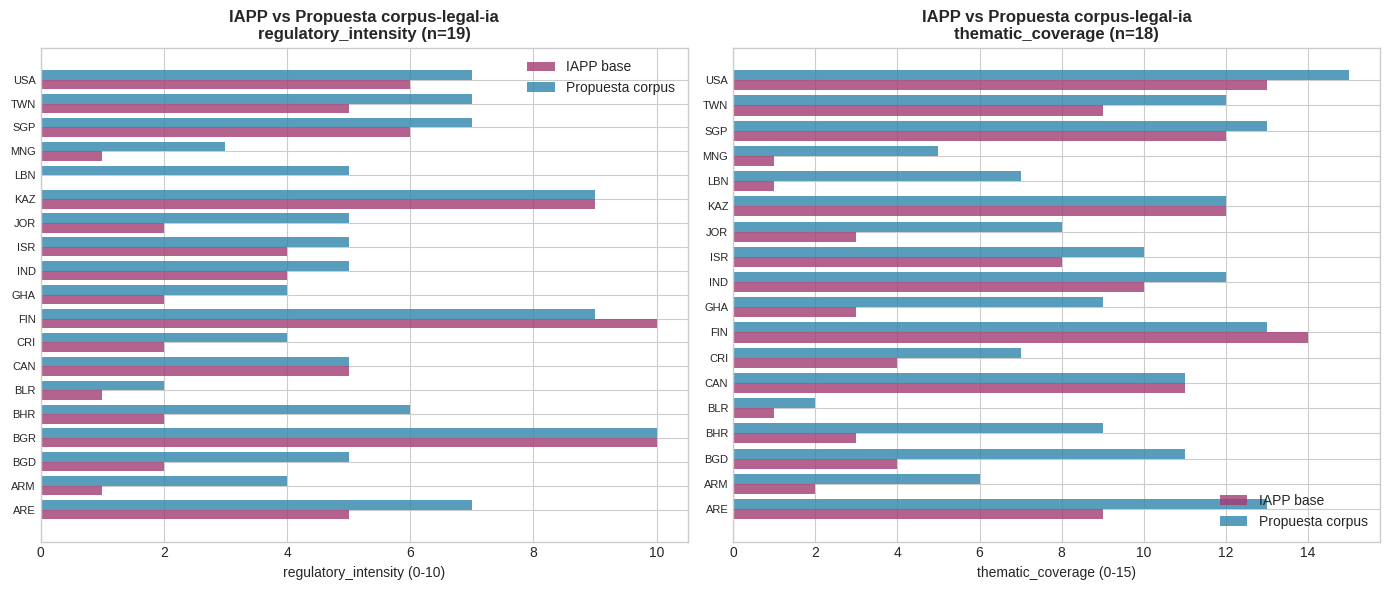


✓ Guardado: ade_v2_02_iapp_vs_proposed.png


In [25]:
# 7.3 Diff plot intensity y coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Intensity
ax = axes[0]
sub = comp.dropna(subset=['regulatory_intensity_proposed','ri_iapp_sample']).sort_values('iso3')
y_pos = np.arange(len(sub))
ax.barh(y_pos - 0.2, sub['ri_iapp_sample'], height=0.4, label='IAPP base', color='#A23B72', alpha=0.8)
ax.barh(y_pos + 0.2, sub['regulatory_intensity_proposed'], height=0.4, label='Propuesta corpus', color='#2E86AB', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(sub['iso3'], fontsize=8)
ax.set_xlabel('regulatory_intensity (0-10)')
ax.set_title(f'IAPP vs Propuesta corpus-legal-ia\nregulatory_intensity (n={len(sub)})',
             fontweight='bold')
ax.legend()

# Coverage
ax = axes[1]
sub = comp.dropna(subset=['thematic_coverage_proposed','tc_iapp_sample']).sort_values('iso3')
y_pos = np.arange(len(sub))
ax.barh(y_pos - 0.2, sub['tc_iapp_sample'], height=0.4, label='IAPP base', color='#A23B72', alpha=0.8)
ax.barh(y_pos + 0.2, sub['thematic_coverage_proposed'], height=0.4, label='Propuesta corpus', color='#2E86AB', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(sub['iso3'], fontsize=8)
ax.set_xlabel('thematic_coverage (0-15)')
ax.set_title(f'IAPP vs Propuesta corpus-legal-ia\nthematic_coverage (n={len(sub)})',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_v2_02_iapp_vs_proposed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Guardado: ade_v2_02_iapp_vs_proposed.png")

In [26]:
# 7.4 Magnitud absoluta de los cambios
abs_diff = comp[['iso3','delta_intensity','delta_coverage']].dropna(how='all', subset=['delta_intensity','delta_coverage'])
abs_diff['abs_delta_intensity'] = abs_diff['delta_intensity'].abs()
abs_diff['abs_delta_coverage'] = abs_diff['delta_coverage'].abs()

print("=== Top cambios absolutos en regulatory_intensity ===")
print(abs_diff.dropna(subset=['delta_intensity']).nlargest(10,'abs_delta_intensity')[['iso3','delta_intensity']])

print("\n=== Top cambios absolutos en thematic_coverage ===")
print(abs_diff.dropna(subset=['delta_coverage']).nlargest(10,'abs_delta_coverage')[['iso3','delta_coverage']])

=== Top cambios absolutos en regulatory_intensity ===
   iso3  delta_intensity
30  LBN              5.0
7   BHR              4.0
1   ARM              3.0
5   BGD              3.0
26  JOR              3.0
0   ARE              2.0
12  CRI              2.0
20  GHA              2.0
31  MNG              2.0
39  TWN              2.0

=== Top cambios absolutos en thematic_coverage ===
   iso3  delta_coverage
5   BGD             7.0
7   BHR             6.0
20  GHA             6.0
30  LBN             6.0
26  JOR             5.0
0   ARE             4.0
1   ARM             4.0
31  MNG             4.0
12  CRI             3.0
39  TWN             3.0


## 8. Análisis por Grupo Regulatorio (IAPP)

In [27]:
# 8.1 Distribución regulatory_status_group
print("=== Distribución de Grupos Regulatorios (N=72, IAPP) ===")
group_dist = df_ade['regulatory_status_group'].value_counts()
print(group_dist)
group_pct = (group_dist / len(df_ade) * 100).round(1)
print("\nPorcentajes:")
for grp, pct in group_pct.items():
    print(f"  {grp}: {pct}%")

=== Distribución de Grupos Regulatorios (N=72, IAPP) ===
regulatory_status_group
strategy_only         33
binding_regulation    28
soft_framework         9
no_framework           2
Name: count, dtype: int64

Porcentajes:
  strategy_only: 45.8%
  binding_regulation: 38.9%
  soft_framework: 12.5%
  no_framework: 2.8%


In [28]:
# 8.2 Media de Y por grupo regulatorio IAPP
print("\n=== Media Y por regulatory_status_group (IAPP) ===")
y_by_group = df_ade.groupby('regulatory_status_group')[y_vars].agg(['mean','std','count']).round(2)
print(y_by_group)


=== Media Y por regulatory_status_group (IAPP) ===
                        ai_readiness_score              ai_adoption_rate  \
                                      mean    std count             mean   
regulatory_status_group                                                    
binding_regulation                   66.40   8.52    28            26.94   
no_framework                         34.58   0.46     2            16.75   
soft_framework                       50.17  14.83     9            16.33   
strategy_only                        60.73  11.17    33            23.72   

                                     ai_investment_usd_bn_cumulative         \
                           std count                            mean    std   
regulatory_status_group                                                       
binding_regulation        9.08    28                            6.56  22.39   
no_framework             12.66     2                            0.01   0.01   
soft_framework      

In [29]:
# 8.3 Media de X2 por grupo regulatorio
print("\n=== Media X2 por regulatory_status_group (IAPP) ===")
print(df_ade.groupby('regulatory_status_group')[x2_core_vars].agg(['mean','std']).round(2))


=== Media X2 por regulatory_status_group (IAPP) ===
                        gdp_per_capita_ppp           internet_penetration  \
                                      mean       std                 mean   
regulatory_status_group                                                     
binding_regulation                58672.49  21043.54                91.36   
no_framework                       9081.91   4939.74                61.27   
soft_framework                    30513.09  29188.94                71.43   
strategy_only                     39037.40  32262.61                83.25   

                               gii_score        rd_expenditure        \
                           std      mean    std           mean   std   
regulatory_status_group                                                
binding_regulation        4.69     45.11  10.23           1.95  1.19   
no_framework             27.38     20.90   3.84            NaN   NaN   
soft_framework           27.89     33.13  16.32

## 9. Visualizaciones

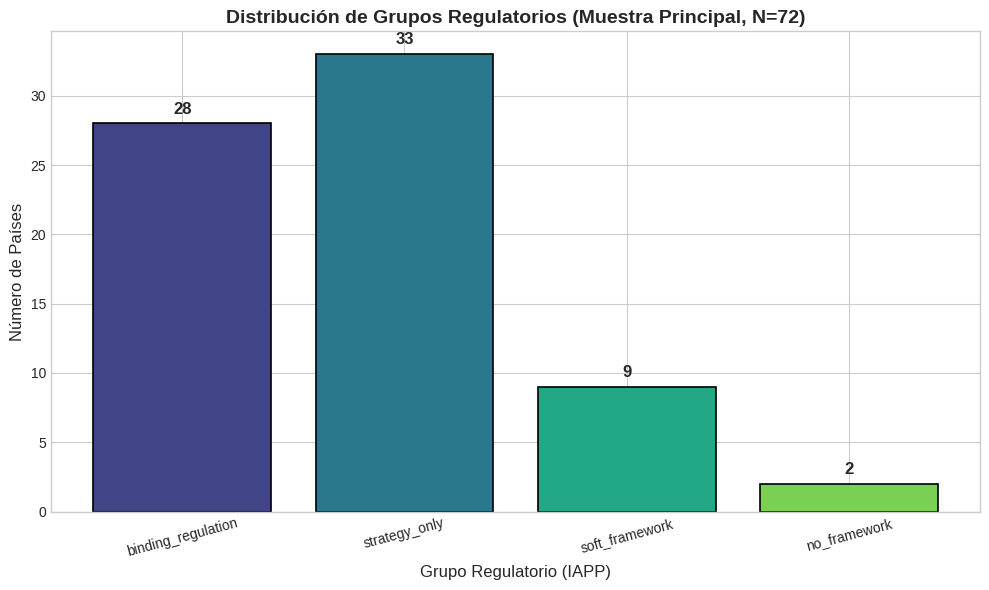

In [30]:
# 9.1 Distribución de grupos regulatorios
fig, ax = plt.subplots(figsize=(10, 6))
group_order = ['binding_regulation', 'strategy_only', 'soft_framework', 'no_framework']
colors = sns.color_palette('viridis', n_colors=4)
group_counts = df_ade['regulatory_status_group'].value_counts().reindex(group_order)
bars = ax.bar(group_order, group_counts.values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Grupo Regulatorio (IAPP)', fontsize=12)
ax.set_ylabel('Número de Países', fontsize=12)
ax.set_title('Distribución de Grupos Regulatorios (Muestra Principal, N=72)',
             fontsize=14, fontweight='bold')
for bar, c in zip(bars, group_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(c),
            ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_01_group_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

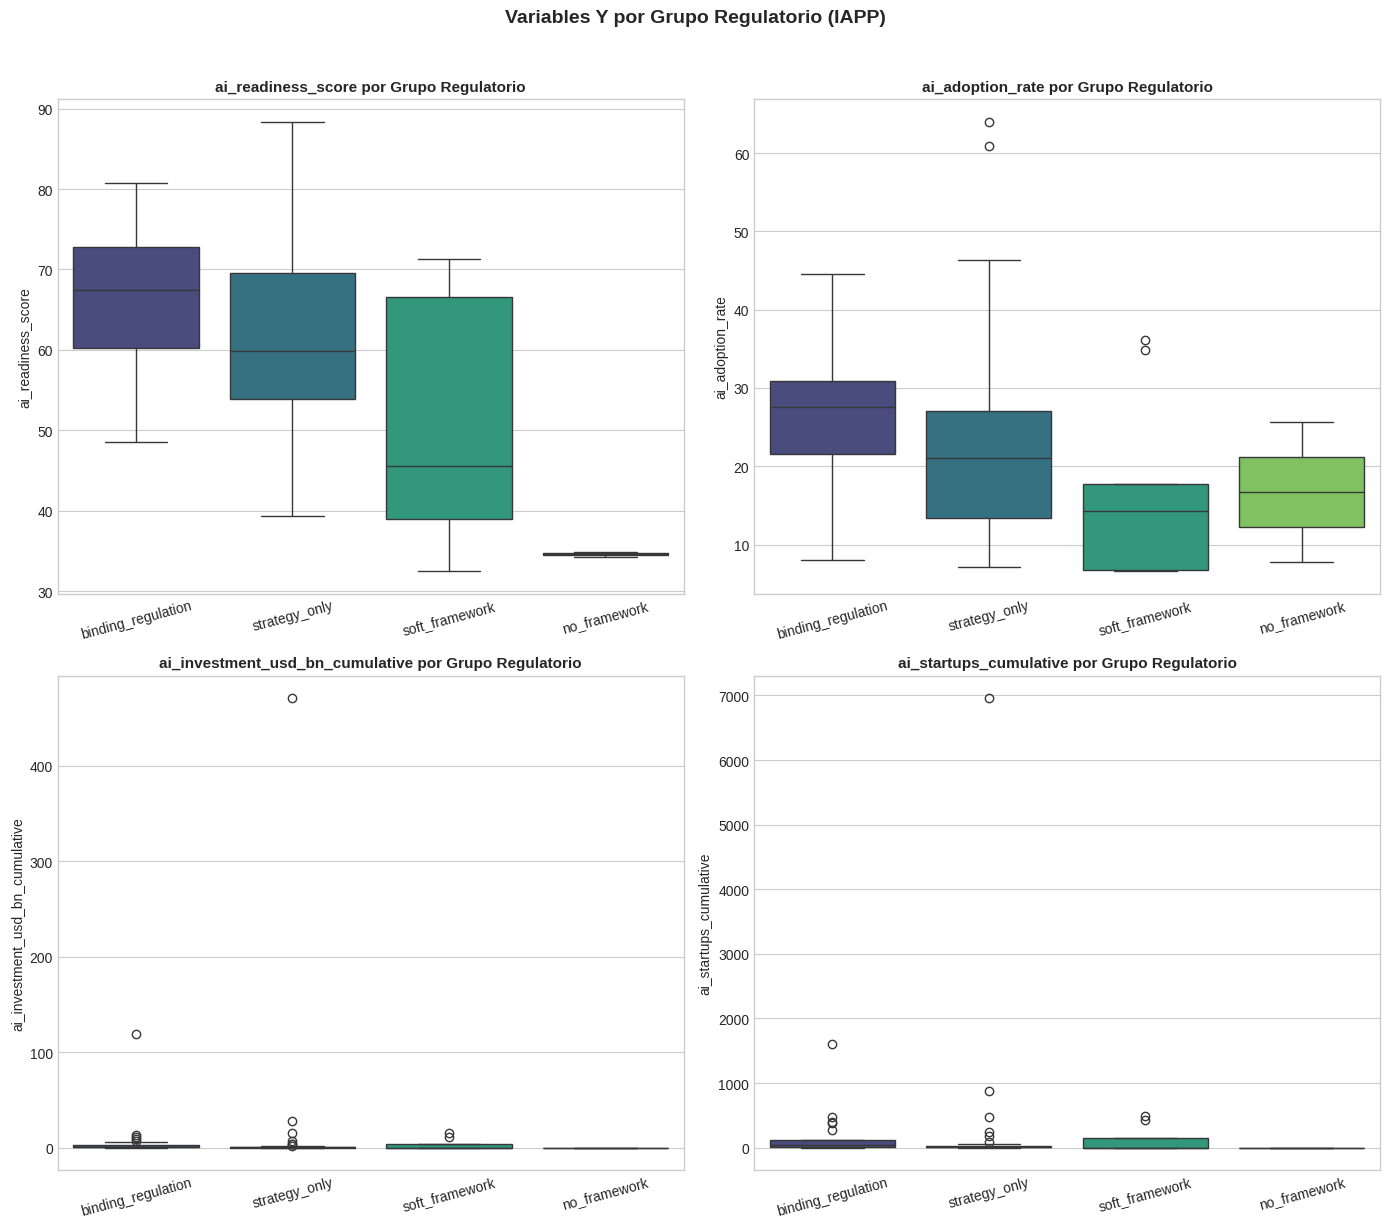

In [31]:
# 9.2 Boxplots Y por grupo regulatorio
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
y_plot_vars = ['ai_readiness_score','ai_adoption_rate',
               'ai_investment_usd_bn_cumulative','ai_startups_cumulative']
for i, var in enumerate(y_plot_vars):
    sns.boxplot(data=df_ade, x='regulatory_status_group', y=var,
                order=group_order, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{var} por Grupo Regulatorio', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Variables Y por Grupo Regulatorio (IAPP)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_02_y_by_regulatory_group.png', dpi=150, bbox_inches='tight')
plt.show()

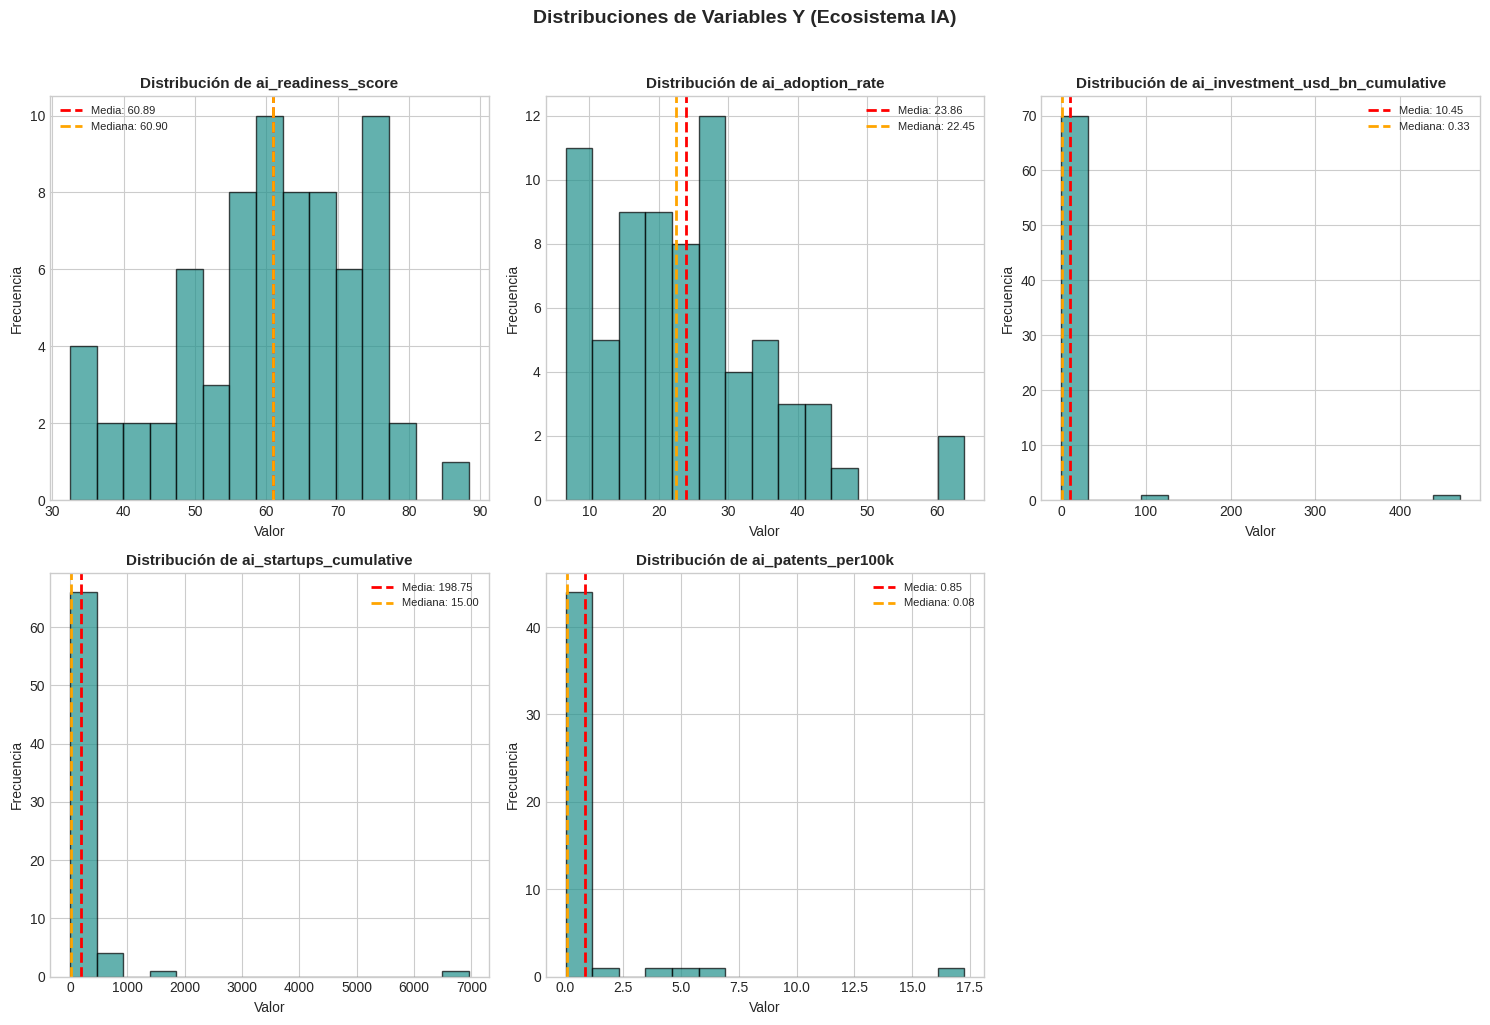

In [32]:
# 9.3 Histogramas de Y
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, var in enumerate(y_vars):
    data = df_ade[var].dropna()
    axes[i].hist(data, bins=15, color=sns.color_palette('viridis',1)[0],
                 edgecolor='black', alpha=0.7)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(f'Distribución de {var}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor'); axes[i].set_ylabel('Frecuencia'); axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Distribuciones de Variables Y (Ecosistema IA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_03_y_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

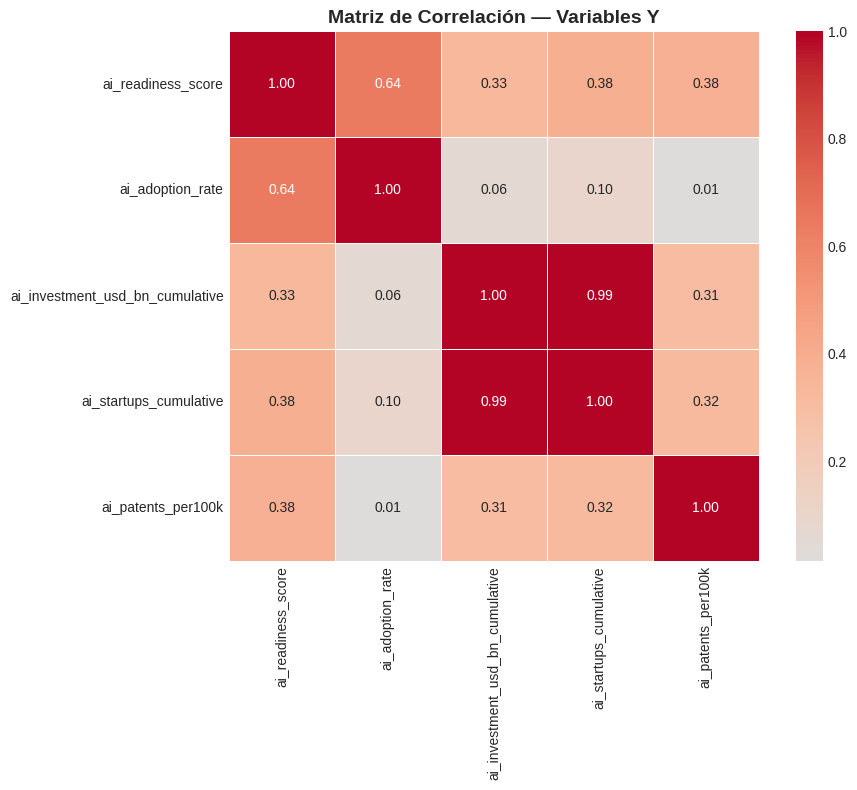

In [33]:
# 9.4 Matriz de correlación Y
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_ade[y_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Matriz de Correlación — Variables Y', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_04_y_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

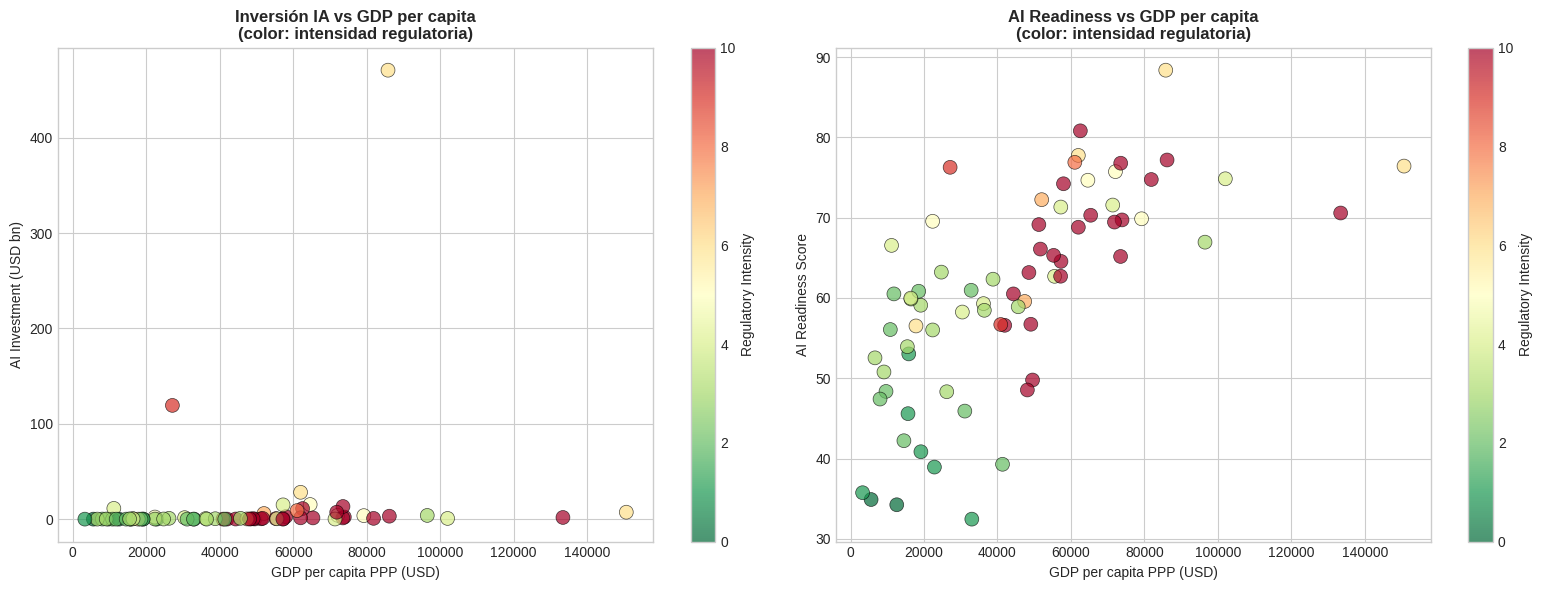

In [34]:
# 9.5 Scatterplots GDP vs outcomes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc1 = axes[0].scatter(df_ade['gdp_per_capita_ppp'], df_ade['ai_investment_usd_bn_cumulative'],
                      c=df_ade['regulatory_intensity'], cmap='RdYlGn_r', alpha=0.7, s=100,
                      edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('GDP per capita PPP (USD)'); axes[0].set_ylabel('AI Investment (USD bn)')
axes[0].set_title('Inversión IA vs GDP per capita\n(color: intensidad regulatoria)', fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='Regulatory Intensity')

sc2 = axes[1].scatter(df_ade['gdp_per_capita_ppp'], df_ade['ai_readiness_score'],
                      c=df_ade['regulatory_intensity'], cmap='RdYlGn_r', alpha=0.7, s=100,
                      edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('GDP per capita PPP (USD)'); axes[1].set_ylabel('AI Readiness Score')
axes[1].set_title('AI Readiness vs GDP per capita\n(color: intensidad regulatoria)', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Regulatory Intensity')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_05_scatter_gdp_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

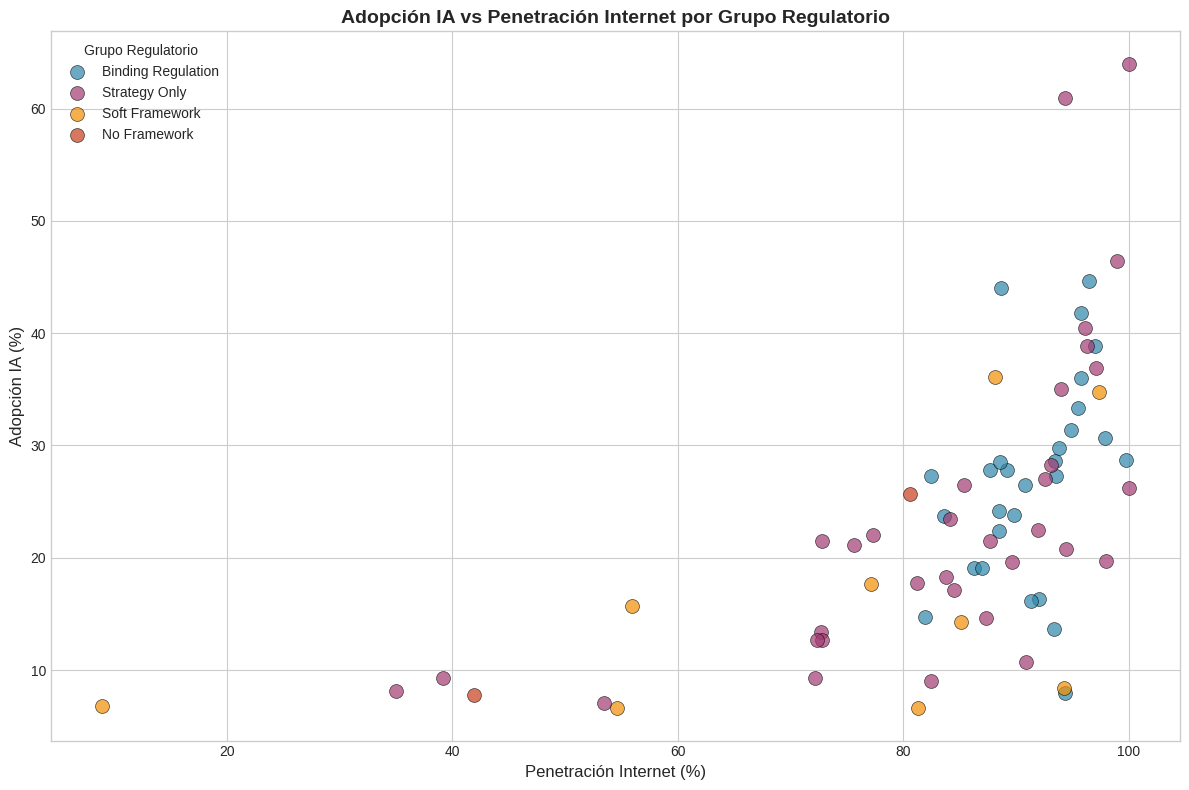

In [35]:
# 9.6 Adopción vs internet penetration por grupo
fig, ax = plt.subplots(figsize=(12, 8))
colors_map = {'binding_regulation': '#2E86AB', 'strategy_only': '#A23B72',
              'soft_framework': '#F18F01', 'no_framework': '#C73E1D'}
for grp in group_order:
    sub = df_ade[df_ade['regulatory_status_group']==grp]
    ax.scatter(sub['internet_penetration'], sub['ai_adoption_rate'],
               c=colors_map[grp], label=grp.replace('_',' ').title(),
               alpha=0.7, s=100, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Penetración Internet (%)', fontsize=12)
ax.set_ylabel('Adopción IA (%)', fontsize=12)
ax.set_title('Adopción IA vs Penetración Internet por Grupo Regulatorio',
             fontsize=14, fontweight='bold')
ax.legend(title='Grupo Regulatorio', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_06_adoption_vs_internet.png', dpi=150, bbox_inches='tight')
plt.show()

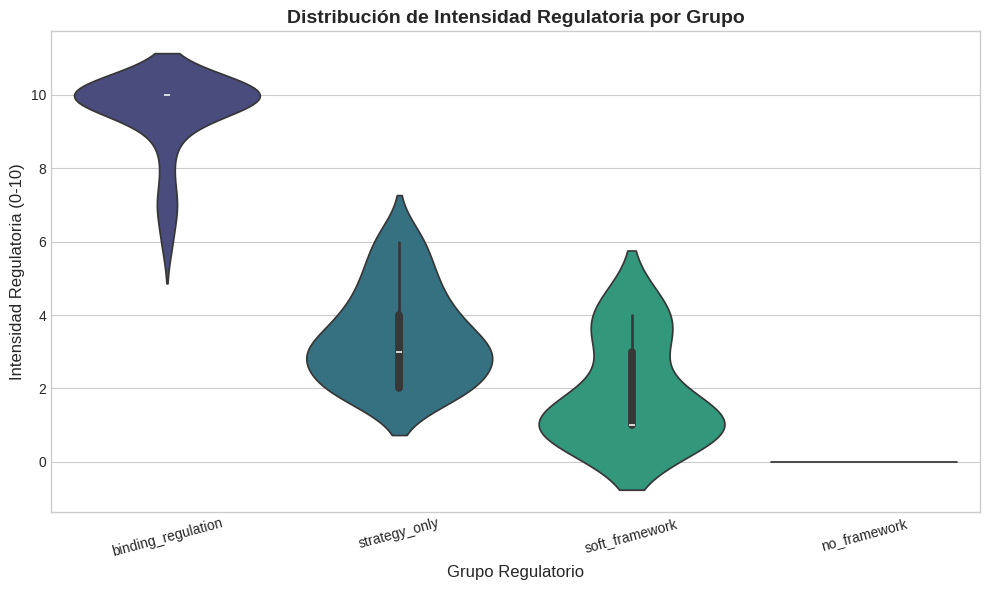

In [36]:
# 9.7 Regulatory Intensity por grupo (violinplot)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_ade, x='regulatory_status_group', y='regulatory_intensity',
               order=group_order, palette='viridis', ax=ax)
ax.set_xlabel('Grupo Regulatorio', fontsize=12)
ax.set_ylabel('Intensidad Regulatoria (0-10)', fontsize=12)
ax.set_title('Distribución de Intensidad Regulatoria por Grupo', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_07_regulatory_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

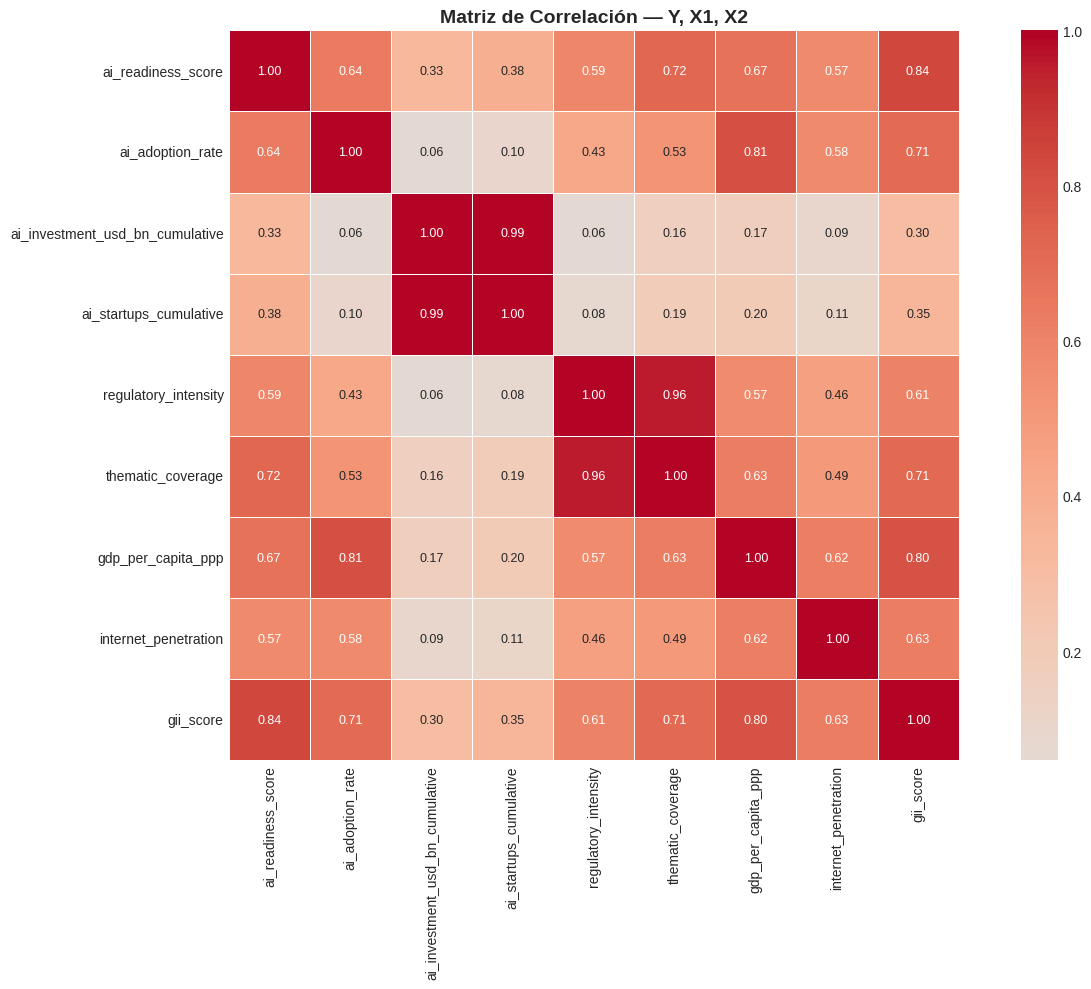

In [37]:
# 9.8 Heatmap correlaciones Y vs X1 + X2
fig, ax = plt.subplots(figsize=(14, 10))
analysis_vars = ['ai_readiness_score','ai_adoption_rate',
                 'ai_investment_usd_bn_cumulative','ai_startups_cumulative',
                 'regulatory_intensity','thematic_coverage',
                 'gdp_per_capita_ppp','internet_penetration','gii_score']
corr_full = df_ade[analysis_vars].corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Matriz de Correlación — Y, X1, X2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_08_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tests Preliminares

In [38]:
# 10.1 ANOVA Y por grupo regulatorio
print("=== ANOVA por Grupo Regulatorio (IAPP) ===\n")
for var in y_vars:
    groups = [g[var].dropna() for _, g in df_ade.groupby('regulatory_status_group')]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        f_stat, p = f_oneway(*groups)
        sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
        print(f"{var}:  F = {f_stat:.3f}, p = {p:.4f} {sig}")

=== ANOVA por Grupo Regulatorio (IAPP) ===

ai_readiness_score:  F = 9.613, p = 0.0000 ***
ai_adoption_rate:  F = 2.033, p = 0.1174 
ai_investment_usd_bn_cumulative:  F = 0.222, p = 0.8806 
ai_startups_cumulative:  F = 0.191, p = 0.9023 
ai_patents_per100k:  F = 0.865, p = 0.4277 


In [39]:
# 10.2 Kruskal-Wallis (no paramétrico)
print("\n=== Kruskal-Wallis ===\n")
for var in y_vars:
    groups = [g[var].dropna() for _, g in df_ade.groupby('regulatory_status_group')]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
        print(f"{var}:  H = {h:.3f}, p = {p:.4f} {sig}")


=== Kruskal-Wallis ===

ai_readiness_score:  H = 15.515, p = 0.0014 ***
ai_adoption_rate:  H = 9.707, p = 0.0212 **
ai_investment_usd_bn_cumulative:  H = 8.311, p = 0.0400 **
ai_startups_cumulative:  H = 10.008, p = 0.0185 **
ai_patents_per100k:  H = 10.450, p = 0.0054 ***


In [40]:
# 10.3 Spearman X1 numerico vs Y
print("\n=== Spearman: X1 IAPP vs Y ===\n")
for x1 in ['regulatory_intensity','thematic_coverage']:
    print(f"{x1}:")
    for y in y_vars:
        data = df_ade[[x1, y]].dropna()
        if len(data) > 5:
            r, p = stats.spearmanr(data[x1], data[y])
            sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
            print(f"  vs {y}: ρ = {r:.3f}, p = {p:.4f} {sig}")
    print()


=== Spearman: X1 IAPP vs Y ===

regulatory_intensity:
  vs ai_readiness_score: ρ = 0.638, p = 0.0000 ***
  vs ai_adoption_rate: ρ = 0.579, p = 0.0000 ***
  vs ai_investment_usd_bn_cumulative: ρ = 0.579, p = 0.0000 ***
  vs ai_startups_cumulative: ρ = 0.585, p = 0.0000 ***
  vs ai_patents_per100k: ρ = 0.532, p = 0.0001 ***

thematic_coverage:
  vs ai_readiness_score: ρ = 0.662, p = 0.0000 ***
  vs ai_adoption_rate: ρ = 0.608, p = 0.0000 ***
  vs ai_investment_usd_bn_cumulative: ρ = 0.615, p = 0.0000 ***
  vs ai_startups_cumulative: ρ = 0.618, p = 0.0000 ***
  vs ai_patents_per100k: ρ = 0.563, p = 0.0000 ***



In [41]:
# 10.4 Comparación: ¿la X1 propuesta correlaciona MEJOR con Y que IAPP?
# Solo para los países con propuesta no-NaN
print("=== ROBUSTNESS: corpus-propuesta vs IAPP en intensity ===\n")
prop_data = comp.merge(df_ade[['iso3'] + y_vars], on='iso3', how='inner')

for y in y_vars:
    # IAPP
    di = prop_data[['ri_iapp_sample', y]].dropna()
    # Propuesta
    dp = prop_data[['regulatory_intensity_proposed', y]].dropna()
    if len(di) > 5 and len(dp) > 5:
        r_iapp, p_iapp = stats.spearmanr(di['ri_iapp_sample'], di[y])
        r_prop, p_prop = stats.spearmanr(dp['regulatory_intensity_proposed'], dp[y])
        print(f"{y}:")
        print(f"  IAPP   (n={len(di)}): ρ = {r_iapp:.3f} (p={p_iapp:.4f})")
        print(f"  Prop.  (n={len(dp)}): ρ = {r_prop:.3f} (p={p_prop:.4f})")
        delta = r_prop - r_iapp
        sign = "↑" if delta > 0 else "↓"
        print(f"  Δ = {delta:+.3f} {sign}\n")

=== ROBUSTNESS: corpus-propuesta vs IAPP en intensity ===

ai_readiness_score:
  IAPP   (n=38): ρ = 0.535 (p=0.0005)
  Prop.  (n=17): ρ = 0.673 (p=0.0031)
  Δ = +0.137 ↑

ai_adoption_rate:
  IAPP   (n=38): ρ = 0.433 (p=0.0066)
  Prop.  (n=17): ρ = 0.553 (p=0.0214)
  Δ = +0.119 ↑

ai_investment_usd_bn_cumulative:
  IAPP   (n=38): ρ = 0.379 (p=0.0191)
  Prop.  (n=17): ρ = 0.408 (p=0.1038)
  Δ = +0.030 ↑

ai_startups_cumulative:
  IAPP   (n=38): ρ = 0.424 (p=0.0081)
  Prop.  (n=17): ρ = 0.462 (p=0.0619)
  Δ = +0.038 ↑

ai_patents_per100k:
  IAPP   (n=28): ρ = 0.112 (p=0.5722)
  Prop.  (n=8): ρ = 0.562 (p=0.1472)
  Δ = +0.450 ↑



## 11. Variables Nuevas del Corpus (autoridad IA y pathway)

`has_dedicated_ai_authority` y `ai_law_pathway_declared` son señales binarias derivadas
de los `CANDIDATES.md` por la skill, no presentes en IAPP.

In [42]:
# 11.1 Cruce con outcomes Y
authority_df = x1v2.merge(df_ade[['iso3'] + y_vars], on='iso3', how='inner')

print("=== AI Readiness por has_dedicated_ai_authority ===")
print(authority_df.groupby('has_dedicated_ai_authority')['ai_readiness_score'].agg(['mean','std','count']).round(2))

print("\n=== AI Adoption por has_dedicated_ai_authority ===")
print(authority_df.groupby('has_dedicated_ai_authority')['ai_adoption_rate'].agg(['mean','std','count']).round(2))

print("\n=== AI Readiness por ai_law_pathway_declared ===")
print(authority_df.groupby('ai_law_pathway_declared')['ai_readiness_score'].agg(['mean','std','count']).round(2))

=== AI Readiness por has_dedicated_ai_authority ===
                             mean    std  count
has_dedicated_ai_authority                     
0                           62.01  12.19     15
1                           65.71  15.64     23

=== AI Adoption por has_dedicated_ai_authority ===
                             mean    std  count
has_dedicated_ai_authority                     
0                           26.75  11.08     15
1                           31.67  14.78     23

=== AI Readiness por ai_law_pathway_declared ===
                          mean    std  count
ai_law_pathway_declared                     
0                        64.11  14.72     17
1                        64.36  14.34     21


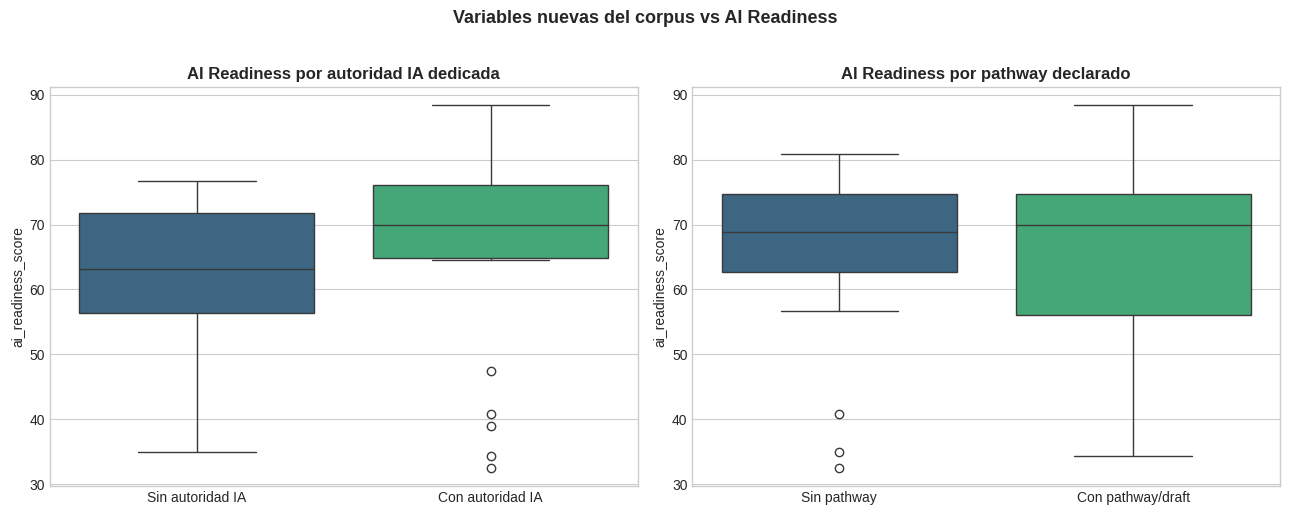


✓ Guardado: ade_v2_03_corpus_extras_vs_y.png


In [43]:
# 11.2 Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# has_dedicated_ai_authority vs readiness
ax = axes[0]
sns.boxplot(data=authority_df, x='has_dedicated_ai_authority',
            y='ai_readiness_score', palette='viridis', ax=ax)
ax.set_xticklabels(['Sin autoridad IA', 'Con autoridad IA'])
ax.set_xlabel('')
ax.set_title('AI Readiness por autoridad IA dedicada', fontweight='bold')

# ai_law_pathway_declared vs readiness
ax = axes[1]
sns.boxplot(data=authority_df, x='ai_law_pathway_declared',
            y='ai_readiness_score', palette='viridis', ax=ax)
ax.set_xticklabels(['Sin pathway', 'Con pathway/draft'])
ax.set_xlabel('')
ax.set_title('AI Readiness por pathway declarado', fontweight='bold')

plt.suptitle('Variables nuevas del corpus vs AI Readiness', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_PATH}ade_v2_03_corpus_extras_vs_y.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Guardado: ade_v2_03_corpus_extras_vs_y.png")

In [44]:
# 11.3 Test t-tests (autoridad sí/no)
print("=== T-tests: has_dedicated_ai_authority ===\n")
for y in y_vars:
    g0 = authority_df[authority_df['has_dedicated_ai_authority']==0][y].dropna()
    g1 = authority_df[authority_df['has_dedicated_ai_authority']==1][y].dropna()
    if len(g0) > 1 and len(g1) > 1:
        t, p = stats.ttest_ind(g0, g1, equal_var=False)
        sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
        print(f"{y}: t = {t:.3f}, p = {p:.4f} {sig}  (n0={len(g0)}, n1={len(g1)})")

=== T-tests: has_dedicated_ai_authority ===

ai_readiness_score: t = -0.817, p = 0.4198   (n0=15, n1=23)
ai_adoption_rate: t = -1.170, p = 0.2500   (n0=15, n1=23)
ai_investment_usd_bn_cumulative: t = -1.105, p = 0.2810   (n0=15, n1=23)
ai_startups_cumulative: t = -1.159, p = 0.2584   (n0=15, n1=23)
ai_patents_per100k: t = -0.901, p = 0.3782   (n0=11, n1=17)


## 12. Posición Descriptiva de Chile en la Muestra

> **Nota:** Chile está marcado como `PENDING` en el corpus legal-IA — no se ha extraído
> aún el corpus de la skill. Este bloque es descriptivo de la fila base de Chile en
> `sample_ready_cross_section.csv`. El análisis SCM contrafactual está reservado al
> sub-estudio MVP focal (no incluido en este ADE).

In [45]:
# 12.1 Chile en el dataset
chile = df_ade[df_ade['iso3'] == 'CHL']

if len(chile) > 0:
    print("=== CHILE en el dataset (X1 IAPP base) ===\n")
    chile_vars_to_show = ['iso3','regulatory_approach','regulatory_intensity',
                          'has_ai_law','enforcement_level','thematic_coverage',
                          'regulatory_status_group']
    for v in chile_vars_to_show:
        if v in chile.columns:
            print(f"  {v}: {chile[v].values[0]}")

    print("\n--- Y (Ecosistema) ---")
    for v in y_vars:
        if v in chile.columns:
            val = chile[v].values[0]
            print(f"  {v}: {val if pd.notna(val) else 'N/A'}")

    print("\n--- X2 Core ---")
    for v in x2_core_vars:
        if v in chile.columns:
            val = chile[v].values[0]
            print(f"  {v}: {val if pd.notna(val) else 'N/A'}")

    print("\n--- Confounders ---")
    for v in ['legal_origin','gdpr_similarity_level','fh_total_score']:
        if v in chile.columns:
            print(f"  {v}: {chile[v].values[0]}")

    # Status corpus
    print(f"\n--- Estado corpus legal-IA ---")
    print(f"  CHL en x1_master_v2: {'SÍ' if 'CHL' in x1v2['iso3'].values else 'NO (PENDING)'}")

=== CHILE en el dataset (X1 IAPP base) ===

  iso3: CHL
  regulatory_approach: strategy_led
  regulatory_intensity: 4
  has_ai_law: 0
  enforcement_level: low
  thematic_coverage: 8
  regulatory_status_group: strategy_only

--- Y (Ecosistema) ---
  ai_readiness_score: 59.3
  ai_adoption_rate: 20.8
  ai_investment_usd_bn_cumulative: 0.68210051
  ai_startups_cumulative: 17.0
  ai_patents_per100k: 0.005086771

--- X2 Core ---
  gdp_per_capita_ppp: 36181.156616977
  internet_penetration: 94.4574
  gii_score: 33.0660923295208
  rd_expenditure: 0.36041
  tertiary_education: 104.734062194824

--- Confounders ---
  legal_origin: French
  gdpr_similarity_level: 2
  fh_total_score: 94

--- Estado corpus legal-IA ---
  CHL en x1_master_v2: NO (PENDING)


In [46]:
# 12.2 Chile vs muestra (descriptivo, no causal)
print("\n=== Posición de Chile vs mediana de muestra ===\n")
for v in ['ai_readiness_score','ai_adoption_rate','ai_investment_usd_bn_cumulative',
          'gdp_per_capita_ppp','regulatory_intensity']:
    val = chile[v].values[0]
    med = df_ade[v].median()
    mean_ = df_ade[v].mean()
    if pd.notna(val):
        pos = "sobre" if val > med else "bajo"
        pct = (df_ade[v] < val).sum() / len(df_ade) * 100
        print(f"{v}:")
        print(f"  Chile: {val:.2f}")
        print(f"  Mediana: {med:.2f} | Media: {mean_:.2f}")
        print(f"  Chile está {pos} mediana ({pct:.0f}% paises por debajo)\n")


=== Posición de Chile vs mediana de muestra ===

ai_readiness_score:
  Chile: 59.30
  Mediana: 60.90 | Media: 60.89
  Chile está bajo mediana (40% paises por debajo)

ai_adoption_rate:
  Chile: 20.80
  Mediana: 22.45 | Media: 23.86
  Chile está bajo mediana (42% paises por debajo)

ai_investment_usd_bn_cumulative:
  Chile: 0.68
  Mediana: 0.33 | Media: 10.45
  Chile está sobre mediana (58% paises por debajo)

gdp_per_capita_ppp:
  Chile: 36181.16
  Mediana: 43148.33 | Media: 44775.63
  Chile está bajo mediana (42% paises por debajo)

regulatory_intensity:
  Chile: 4.00
  Mediana: 4.00 | Media: 5.50
  Chile está bajo mediana (40% paises por debajo)



## 13. Tablas Resumen para Exportar

In [47]:
# 13.1 Resumen estadísticas por grupo regulatorio (IAPP)
summary_by_group = df_ade.groupby('regulatory_status_group').agg({
    'ai_readiness_score': ['mean','std','count'],
    'ai_adoption_rate': ['mean','std'],
    'ai_investment_usd_bn_cumulative': ['mean','std'],
    'ai_startups_cumulative': ['mean','std'],
    'regulatory_intensity': ['mean','std'],
    'gdp_per_capita_ppp': ['mean','std'],
    'internet_penetration': ['mean','std'],
    'gii_score': ['mean','std']
}).round(2)
summary_by_group.to_csv(f'{OUTPUTS_PATH}ade_summary_by_group.csv')
print(f"✓ Guardado: ade_summary_by_group.csv")
print(summary_by_group)

✓ Guardado: ade_summary_by_group.csv
                        ai_readiness_score              ai_adoption_rate  \
                                      mean    std count             mean   
regulatory_status_group                                                    
binding_regulation                   66.40   8.52    28            26.94   
no_framework                         34.58   0.46     2            16.75   
soft_framework                       50.17  14.83     9            16.33   
strategy_only                        60.73  11.17    33            23.72   

                               ai_investment_usd_bn_cumulative         \
                           std                            mean    std   
regulatory_status_group                                                 
binding_regulation        9.08                            6.56  22.39   
no_framework             12.66                            0.01   0.01   
soft_framework           11.63                            3.35   

In [48]:
# 13.2 Matriz correlación Y
corr_matrix = df_ade[y_vars].corr().round(3)
corr_matrix.to_csv(f'{OUTPUTS_PATH}ade_correlation_matrix_y.csv')
print(f"✓ Guardado: ade_correlation_matrix_y.csv")
print(corr_matrix)

✓ Guardado: ade_correlation_matrix_y.csv
                                 ai_readiness_score  ai_adoption_rate  \
ai_readiness_score                            1.000             0.637   
ai_adoption_rate                              0.637             1.000   
ai_investment_usd_bn_cumulative               0.334             0.059   
ai_startups_cumulative                        0.384             0.100   
ai_patents_per100k                            0.377             0.014   

                                 ai_investment_usd_bn_cumulative  \
ai_readiness_score                                         0.334   
ai_adoption_rate                                           0.059   
ai_investment_usd_bn_cumulative                            1.000   
ai_startups_cumulative                                     0.994   
ai_patents_per100k                                         0.311   

                                 ai_startups_cumulative  ai_patents_per100k  
ai_readiness_score               

In [49]:
# 13.3 Lista de paises con datos
countries_list = df_ade[['iso3','regulatory_status_group','regulatory_intensity',
                         'ai_readiness_score','ai_adoption_rate',
                         'ai_investment_usd_bn_cumulative','ai_startups_cumulative',
                         'gdp_per_capita_ppp','gii_score']].copy()
countries_list = countries_list.sort_values('ai_readiness_score', ascending=False)
countries_list.to_csv(f'{OUTPUTS_PATH}ade_countries_list.csv', index=False)
print(f"✓ Guardado: ade_countries_list.csv")
print(countries_list.head(15))

✓ Guardado: ade_countries_list.csv
   iso3 regulatory_status_group  regulatory_intensity  ai_readiness_score  \
83  USA           strategy_only                     6               88.36   
29  FRA      binding_regulation                    10               80.81   
30  GBR           strategy_only                     6               77.75   
58  NLD      binding_regulation                    10               77.18   
45  KOR      binding_regulation                     8               76.89   
22  DEU      binding_regulation                    10               76.78   
70  SGP           strategy_only                     6               76.42   
16  CHN      binding_regulation                     9               76.27   
3   AUS           strategy_only                     5               75.73   
59  NOR           strategy_only                     4               74.84   
23  DNK      binding_regulation                    10               74.75   
13  CAN           strategy_only          

In [50]:
# 13.4 NUEVO: tabla comparativa IAPP vs Propuesta corpus
comp_export = comp[['iso3',
                    'ri_iapp_sample','regulatory_intensity_proposed','delta_intensity',
                    'tc_iapp_sample','thematic_coverage_proposed','delta_coverage',
                    'regime_iapp_sample','regulatory_regime_group_proposed',
                    'has_dedicated_ai_authority','ai_law_pathway_declared',
                    'ai_corpus_n_documents','ai_corpus_total_pages']].copy()
comp_export = comp_export.rename(columns={
    'ri_iapp_sample':'regulatory_intensity_iapp',
    'tc_iapp_sample':'thematic_coverage_iapp',
    'regime_iapp_sample':'regulatory_regime_group_iapp',
})
comp_export.to_csv(f'{OUTPUTS_PATH}ade_v2_iapp_vs_proposed.csv', index=False)
print(f"✓ Guardado: ade_v2_iapp_vs_proposed.csv")
print(comp_export.head(20))

✓ Guardado: ade_v2_iapp_vs_proposed.csv
   iso3  regulatory_intensity_iapp  regulatory_intensity_proposed  \
0   ARE                        5.0                            7.0   
1   ARM                        1.0                            4.0   
2   AUS                        5.0                            NaN   
3   AUT                       10.0                            NaN   
4   BEL                       10.0                            NaN   
5   BGD                        2.0                            5.0   
6   BGR                       10.0                           10.0   
7   BHR                        2.0                            6.0   
8   BLR                        1.0                            2.0   
9   CAN                        5.0                            5.0   
10  CHE                        3.0                            NaN   
11  CMR                        0.0                            NaN   
12  CRI                        2.0                            4

In [51]:
# 13.5 NUEVO: tabla cobertura corpus por país
df_corpus_status_export = df[['iso3','region']].copy()
df_corpus_status_export['has_corpus'] = df_corpus_status_export['iso3'].isin(in_sample_done).astype(int)
df_corpus_status_export = df_corpus_status_export.merge(
    x1v2[['iso3','ai_corpus_n_documents','ai_corpus_total_pages',
          'regulatory_regime_group_proposed','has_dedicated_ai_authority',
          'ai_law_pathway_declared']],
    on='iso3', how='left'
)
df_corpus_status_export.to_csv(f'{OUTPUTS_PATH}ade_v2_corpus_status_per_country.csv', index=False)
print(f"✓ Guardado: ade_v2_corpus_status_per_country.csv")
print(df_corpus_status_export.head(15))

✓ Guardado: ade_v2_corpus_status_per_country.csv
   iso3                                   region  has_corpus  \
0   ARE         Northern Africa and Western Asia           1   
1   ARG          Latin America and the Caribbean           0   
2   ARM         Northern Africa and Western Asia           1   
3   AUS  South East Asia, East Asia, and Oceania           1   
4   AUT                                   Europe           1   
5   BEL                                   Europe           1   
6   BGD                Central and Southern Asia           1   
7   BGR                                   Europe           1   
8   BHR         Northern Africa and Western Asia           1   
9   BLR                                   Europe           1   
10  BLZ          Latin America and the Caribbean           0   
11  BRA          Latin America and the Caribbean           0   
12  BRB          Latin America and the Caribbean           0   
13  CAN                         Northern America       

## 14. Conclusiones del ADE v2

In [52]:
# 14.1 Hallazgos clave
print("="*60)
print("HALLAZGOS CLAVE DEL ADE v2")
print("="*60)

print("\n1. ESTADO DEL CORPUS LEGAL-IA:")
print(f"   Países procesados (DONE): {len(in_sample_done)}/{len(sample_set)}")
print(f"   Países pendientes: {len(pending)}")
print(f"   Países fuera muestra (referencia): {sorted(out_sample_done)}")

print("\n2. DISTRIBUCIÓN GRUPOS REGULATORIOS (IAPP, N=72):")
for grp in group_order:
    n = (df_ade['regulatory_status_group'] == grp).sum()
    print(f"   {grp}: {n} países ({n/len(df_ade)*100:.1f}%)")

print("\n3. MEDIA AI READINESS POR GRUPO:")
for grp in group_order:
    m = df_ade[df_ade['regulatory_status_group']==grp]['ai_readiness_score'].mean()
    print(f"   {grp}: {m:.2f}")

print("\n4. CORRELACIONES X1 vs Y (IAPP):")
for x1 in ['regulatory_intensity','thematic_coverage']:
    for y in ['ai_readiness_score','ai_adoption_rate','ai_investment_usd_bn_cumulative']:
        r = df_ade[[x1,y]].corr().iloc[0,1]
        print(f"   {x1} vs {y}: ρ = {r:.3f}")

print("\n5. X1 IAPP vs PROPUESTA CORPUS:")
print(f"   Países con propuesta intensity: {comp['regulatory_intensity_proposed'].notna().sum()}")
print(f"   Países con propuesta coverage: {comp['thematic_coverage_proposed'].notna().sum()}")
print(f"   Países con cambio de regime propuesto: {len(changed_regime)}")
print(f"   Δ medio intensity (prop - iapp): {comp['delta_intensity'].dropna().mean():.2f}")
print(f"   Δ medio coverage (prop - iapp): {comp['delta_coverage'].dropna().mean():.2f}")

print("\n6. VARIABLES NUEVAS DEL CORPUS:")
print(f"   has_dedicated_ai_authority = 1: {(x1v2['has_dedicated_ai_authority']==1).sum()}/{len(x1v2)}")
print(f"   ai_law_pathway_declared = 1: {(x1v2['ai_law_pathway_declared']==1).sum()}/{len(x1v2)}")

print("\n7. CHILE (POSICIÓN DESCRIPTIVA):")
print(f"   Status corpus legal-IA: PENDING (no procesado aún)")
chile_ri = chile['regulatory_intensity'].values[0]
print(f"   regulatory_intensity (IAPP): {chile_ri} (media muestra: {df_ade['regulatory_intensity'].mean():.2f})")
print(f"   regulatory_status_group (IAPP): {chile['regulatory_status_group'].values[0]}")
print(f"   ai_readiness_score: {chile['ai_readiness_score'].values[0]:.2f} (mediana: {df_ade['ai_readiness_score'].median():.2f})")

HALLAZGOS CLAVE DEL ADE v2

1. ESTADO DEL CORPUS LEGAL-IA:
   Países procesados (DONE): 41/86
   Países pendientes: 45
   Países fuera muestra (referencia): ['QAT']

2. DISTRIBUCIÓN GRUPOS REGULATORIOS (IAPP, N=72):
   binding_regulation: 28 países (38.9%)
   strategy_only: 33 países (45.8%)
   soft_framework: 9 países (12.5%)
   no_framework: 2 países (2.8%)

3. MEDIA AI READINESS POR GRUPO:
   binding_regulation: 66.40
   strategy_only: 60.73
   soft_framework: 50.17
   no_framework: 34.58

4. CORRELACIONES X1 vs Y (IAPP):
   regulatory_intensity vs ai_readiness_score: ρ = 0.588
   regulatory_intensity vs ai_adoption_rate: ρ = 0.427
   regulatory_intensity vs ai_investment_usd_bn_cumulative: ρ = 0.060
   thematic_coverage vs ai_readiness_score: ρ = 0.722
   thematic_coverage vs ai_adoption_rate: ρ = 0.526
   thematic_coverage vs ai_investment_usd_bn_cumulative: ρ = 0.159

5. X1 IAPP vs PROPUESTA CORPUS:
   Países con propuesta intensity: 20
   Países con propuesta coverage: 19
   Paí

In [53]:
# 14.2 Resumen de archivos generados
print("\n" + "="*60)
print("ARCHIVOS GENERADOS EN OUTPUTS/")
print("="*60)
output_files = sorted(os.listdir(OUTPUTS_PATH))
for f in output_files:
    if f.endswith('.png') or f.endswith('.csv'):
        size = os.path.getsize(f'{OUTPUTS_PATH}{f}') / 1024
        print(f"  - {f} ({size:.1f} KB)")
print(f"\n✓ Total: {sum(1 for f in output_files if f.endswith(('.png','.csv')))} archivos")


ARCHIVOS GENERADOS EN OUTPUTS/
  - ade_01_group_distribution.png (66.8 KB)
  - ade_02_y_by_regulatory_group.png (171.5 KB)
  - ade_03_y_distributions.png (134.8 KB)
  - ade_04_y_correlation_matrix.png (93.7 KB)
  - ade_05_scatter_gdp_outcomes.png (161.4 KB)
  - ade_06_adoption_vs_internet.png (112.9 KB)
  - ade_07_regulatory_intensity.png (100.6 KB)
  - ade_08_full_correlation_matrix.png (172.3 KB)
  - ade_correlation_matrix_y.csv (0.3 KB)
  - ade_countries_list.csv (6.0 KB)
  - ade_summary_by_group.csv (0.9 KB)
  - ade_v2_00_corpus_coverage_by_region.png (112.1 KB)
  - ade_v2_01_corpus_metrics.png (91.1 KB)
  - ade_v2_02_iapp_vs_proposed.png (87.0 KB)
  - ade_v2_03_corpus_extras_vs_y.png (56.2 KB)
  - ade_v2_corpus_status_per_country.csv (3.8 KB)
  - ade_v2_iapp_vs_proposed.csv (2.8 KB)

✓ Total: 17 archivos


---

## Notas Finales (v2)

### Limitaciones reconocidas
1. **N = 86 cross-section** sin variación temporal: no panel data, no DiD posible.
2. **48 países pendientes** de corpus legal-IA: la X1 propuesta cubre solo 41 países (40 en muestra + QAT externo).
3. **Selección no aleatoria**: la muestra hereda el sesgo del IAPP Tracker + completitud de WDI.
4. **Endogeneidad regulación↔ecosistema**: bidireccional; no abordable a este nivel descriptivo.
5. **Compounded UE**: efecto Brussels (AI Act) hace difícil separar régimen de cultura UE preexistente.

### Próximos pasos del proyecto
1. **Procesar países pendientes** de P2 + P3 con la skill `corpus-legal-ia` para completar X1 propuesta.
2. **02_limpieza.ipynb** — outliers, transformaciones (log), imputación, codificación categóricas.
3. **04_modelamiento.ipynb** — OLS bivariado/multivariado, K-Means, PCA, robustness con X1 propuesta.
4. **05_nlp.ipynb** — análisis textual del corpus legal-IA (topic modeling, similitud entre marcos regulatorios).

### Sub-estudios paralelos (no incluidos aquí)
- **MVP Top 30** (N=30): submuestra con análisis SCM CHL focal — en desarrollo separado.
- **Proxies de infraestructura** (6 pilotos): `data/raw/proxies/` con DC capacity, grid, EED, water — desarrollado paralelo.

### Referencias
- `../docs/GUIA_ADE_ANALISIS_EXPLORATORIO.md` — guía metodológica del ADE
- `../info_data/DATA_DECISIONS_LOG.md` — bitácora de decisiones de datos
- `../info_data/GUIA_VARIABLES_ESTUDIO_ETL.md` — diccionario completo de variables
- `../docs/HALLAZGOS_DIFERENCIALES.md` — tesis diferenciales por país (38 procesados)
- `../.claude/skills/corpus-legal-ia/sample.md` — tabla maestra de avance de los 86

---

*Notebook v2 actualizado al 2026-04-28 con corpus 38/86 + x1_master_v2 + variables del corpus.*
